# Bước 3: Xử Lý Giá Trị Thiếu (Handling Missing Values)

Giá trị thiếu (NA/NaN) là vấn đề phổ biến trong dữ liệu thực tế.

**Mục tiêu:**
- Phát hiện và đếm giá trị thiếu
- Phân tích pattern của missing data
- Đề xuất và thực hiện chiến lược xử lý

## 3.1 Import thư viện

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path
import warnings

warnings.filterwarnings('ignore')
pd.set_option('display.max_columns', None)

plt.style.use('seaborn-v0_8-whitegrid')
print("✅ Thư viện đã được import thành công!")

✅ Thư viện đã được import thành công!


## 3.2 Tải dữ liệu

In [2]:
DATA_PATH = Path("../data/raw/accepted_2007_to_2018Q4.csv")
SAMPLE_SIZE = 50000

df = pd.read_csv(DATA_PATH, nrows=SAMPLE_SIZE, low_memory=False)
print(f"📊 Đã tải: {df.shape[0]:,} hàng × {df.shape[1]} cột")

📊 Đã tải: 50,000 hàng × 151 cột


## 3.3 Tổng quan giá trị thiếu

In [3]:
print("=" * 70)
print("📊 TỔNG QUAN GIÁ TRỊ THIẾU")
print("=" * 70)

total_cells = df.shape[0] * df.shape[1]
total_missing = df.isnull().sum().sum()
total_missing_pct = (total_missing / total_cells * 100)

print(f"Tổng số ô: {total_cells:,}")
print(f"Tổng số thiếu: {total_missing:,}")
print(f"Tỷ lệ thiếu: {total_missing_pct:.2f}%")

📊 TỔNG QUAN GIÁ TRỊ THIẾU
Tổng số ô: 7,550,000
Tổng số thiếu: 2,519,025
Tỷ lệ thiếu: 33.36%


## 3.4 Đếm giá trị thiếu theo cột

In [4]:
print("=" * 70)
print("📋 GIÁ TRỊ THIẾU THEO CỘT (df.isnull().sum())")
print("=" * 70)

# Tính toán missing values
missing = df.isnull().sum()
missing_pct = (missing / len(df) * 100).round(2)

missing_df = pd.DataFrame({
    'Cột': missing.index,
    'Số thiếu': missing.values,
    'Tỷ lệ %': missing_pct.values
})
missing_df = missing_df.sort_values('Tỷ lệ %', ascending=False)
missing_df = missing_df[missing_df['Số thiếu'] > 0]

print(f"\nSố cột có giá trị thiếu: {len(missing_df)} / {len(df.columns)}")
print("\n" + missing_df.to_string(index=False))

📋 GIÁ TRỊ THIẾU THEO CỘT (df.isnull().sum())

Số cột có giá trị thiếu: 72 / 151

                                       Cột  Số thiếu  Tỷ lệ %
                                 member_id     50000   100.00
                     sec_app_num_rev_accts     50000   100.00
                       sec_app_open_act_il     50000   100.00
                    sec_app_inq_last_6mths     50000   100.00
                          sec_app_open_acc     50000   100.00
                          sec_app_mort_acc     50000   100.00
       sec_app_mths_since_last_major_derog     50000   100.00
        sec_app_collections_12_mths_ex_med     50000   100.00
          sec_app_chargeoff_within_12_mths     50000   100.00
                    sec_app_fico_range_low     50000   100.00
                  sec_app_earliest_cr_line     50000   100.00
                        sec_app_revol_util     50000   100.00
                   sec_app_fico_range_high     50000   100.00
                           revol_bal_joint     5000

## 3.5 Phân loại mức độ thiếu

In [5]:
print("=" * 70)
print("📊 PHÂN LOẠI MỨC ĐỘ THIẾU")
print("=" * 70)

def phan_loai_missing(pct):
    if pct == 0:
        return 'Hoàn chỉnh (0%)'
    elif pct < 5:
        return 'Thấp (<5%)'
    elif pct < 25:
        return 'Trung bình (5-25%)'
    elif pct < 50:
        return 'Cao (25-50%)'
    elif pct < 75:
        return 'Rất cao (50-75%)'
    else:
        return 'Nghiêm trọng (>75%)'

# Áp dụng phân loại cho tất cả cột
all_missing_pct = (df.isnull().sum() / len(df) * 100)
all_categories = all_missing_pct.apply(phan_loai_missing)
category_counts = all_categories.value_counts()

print("\nSố cột theo mức độ thiếu:")
for cat, count in category_counts.items():
    print(f"  {cat}: {count} cột")

📊 PHÂN LOẠI MỨC ĐỘ THIẾU

Số cột theo mức độ thiếu:
  Hoàn chỉnh (0%): 79 cột
  Nghiêm trọng (>75%): 40 cột
  Rất cao (50-75%): 17 cột
  Thấp (<5%): 10 cột
  Trung bình (5-25%): 4 cột
  Cao (25-50%): 1 cột


## 3.6 Trực quan hóa giá trị thiếu

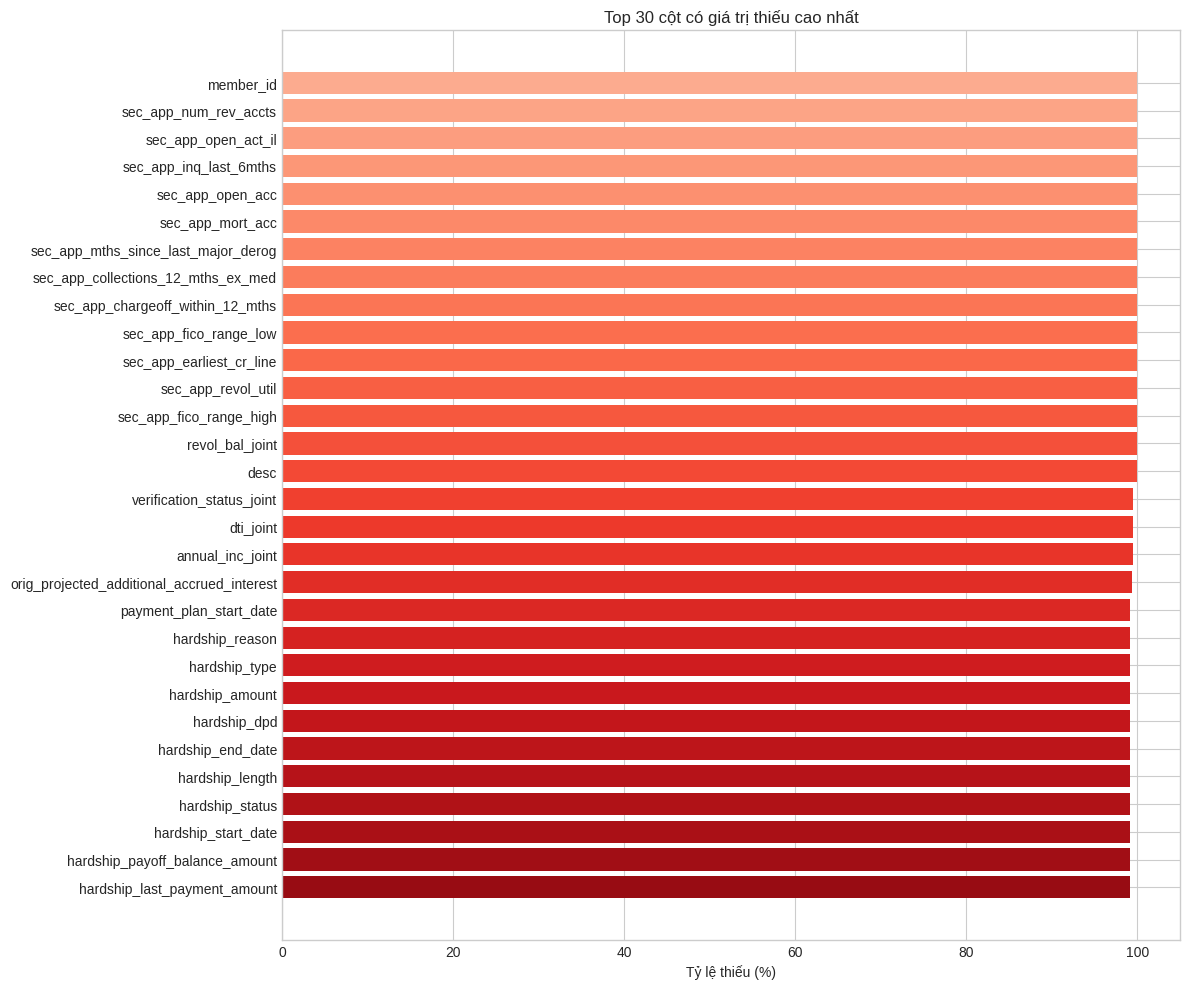

In [6]:
# Biểu đồ thanh cho top 30 cột
plt.figure(figsize=(12, 10))
top_30 = missing_df.head(30)
colors = plt.cm.Reds(np.linspace(0.3, 0.9, len(top_30)))

plt.barh(range(len(top_30)), top_30['Tỷ lệ %'].values, color=colors)
plt.yticks(range(len(top_30)), top_30['Cột'].values)
plt.xlabel('Tỷ lệ thiếu (%)')
plt.title('Top 30 cột có giá trị thiếu cao nhất')
plt.gca().invert_yaxis()
plt.tight_layout()
plt.savefig('outputs/03_missing_values.png', dpi=150, bbox_inches='tight')
plt.show()

## 3.7 Chiến lược xử lý

In [7]:
print("=" * 70)
print("💡 CHIẾN LƯỢC XỬ LÝ GIÁ TRỊ THIẾU")
print("=" * 70)

# Phân loại cột theo chiến lược xử lý
cols_drop = missing_df[missing_df['Tỷ lệ %'] > 75]['Cột'].tolist()
cols_impute = missing_df[(missing_df['Tỷ lệ %'] > 0) & 
                          (missing_df['Tỷ lệ %'] <= 75)]['Cột'].tolist()

print(f"""
1️⃣ CỘT NÊN XÓA (>75% thiếu): {len(cols_drop)} cột
   Lý do: Quá ít thông tin để xử lý
""")
for col in cols_drop:
    pct = missing_df[missing_df['Cột'] == col]['Tỷ lệ %'].values[0]
    print(f"   ❌ {col}: {pct:.1f}%")

print(f"""
2️⃣ CỘT CẦN IMPUTE (0-75% thiếu): {len(cols_impute)} cột
""")

# Phân loại theo kiểu dữ liệu
num_impute = [col for col in cols_impute if df[col].dtype in ['int64', 'float64']]
cat_impute = [col for col in cols_impute if df[col].dtype == 'object']

print(f"   📊 Biến số ({len(num_impute)} cột): Dùng mean/median")
print(f"   📝 Biến phân loại ({len(cat_impute)} cột): Dùng mode/'Unknown'")

💡 CHIẾN LƯỢC XỬ LÝ GIÁ TRỊ THIẾU

1️⃣ CỘT NÊN XÓA (>75% thiếu): 40 cột
   Lý do: Quá ít thông tin để xử lý

   ❌ member_id: 100.0%
   ❌ sec_app_num_rev_accts: 100.0%
   ❌ sec_app_open_act_il: 100.0%
   ❌ sec_app_inq_last_6mths: 100.0%
   ❌ sec_app_open_acc: 100.0%
   ❌ sec_app_mort_acc: 100.0%
   ❌ sec_app_mths_since_last_major_derog: 100.0%
   ❌ sec_app_collections_12_mths_ex_med: 100.0%
   ❌ sec_app_chargeoff_within_12_mths: 100.0%
   ❌ sec_app_fico_range_low: 100.0%
   ❌ sec_app_earliest_cr_line: 100.0%
   ❌ sec_app_revol_util: 100.0%
   ❌ sec_app_fico_range_high: 100.0%
   ❌ revol_bal_joint: 100.0%
   ❌ desc: 100.0%
   ❌ verification_status_joint: 99.5%
   ❌ dti_joint: 99.5%
   ❌ annual_inc_joint: 99.5%
   ❌ orig_projected_additional_accrued_interest: 99.3%
   ❌ payment_plan_start_date: 99.2%
   ❌ hardship_reason: 99.2%
   ❌ hardship_type: 99.2%
   ❌ hardship_amount: 99.2%
   ❌ hardship_dpd: 99.2%
   ❌ hardship_end_date: 99.2%
   ❌ hardship_length: 99.2%
   ❌ hardship_status: 99.2%

## 3.8 Thực hiện xử lý

In [8]:
print("=" * 70)
print("🔧 THỰC HIỆN XỬ LÝ")
print("=" * 70)

df_clean = df.copy()
original_rows = len(df_clean)

# Bước 1: Xóa cột >75% missing
print(f"\n1️⃣ Xóa {len(cols_drop)} cột có >75% thiếu...")
df_clean = df_clean.drop(columns=cols_drop, errors='ignore')

# Bước 2: Điền giá trị thiếu cho biến số
print("\n2️⃣ Điền giá trị thiếu cho biến số (median)...")
for col in num_impute:
    if col in df_clean.columns:
        median_val = df_clean[col].median()
        df_clean[col].fillna(median_val, inplace=True)

# Bước 3: Điền giá trị thiếu cho biến phân loại
print("\n3️⃣ Điền giá trị thiếu cho biến phân loại (mode)...")
for col in cat_impute:
    if col in df_clean.columns:
        if df_clean[col].mode().empty:
            df_clean[col].fillna('Unknown', inplace=True)
        else:
            mode_val = df_clean[col].mode().iloc[0]
            df_clean[col].fillna(mode_val, inplace=True)

🔧 THỰC HIỆN XỬ LÝ

1️⃣ Xóa 40 cột có >75% thiếu...

2️⃣ Điền giá trị thiếu cho biến số (median)...

3️⃣ Điền giá trị thiếu cho biến phân loại (mode)...


## 3.9 Kiểm tra kết quả

In [9]:
print("=" * 70)
print("✅ KIỂM TRA KẾT QUẢ SAU XỬ LÝ")
print("=" * 70)

remaining_missing = df_clean.isnull().sum().sum()
print(f"\nTrước xử lý: {total_missing:,} giá trị thiếu")
print(f"Sau xử lý: {remaining_missing:,} giá trị thiếu")
print(f"Số cột: {df.shape[1]} → {df_clean.shape[1]}")
print(f"Số hàng: {original_rows:,} (không đổi)")

# Kiểm tra lại
print("\ndf_clean.isnull().sum():")
print(df_clean.isnull().sum().sum())

✅ KIỂM TRA KẾT QUẢ SAU XỬ LÝ

Trước xử lý: 2,519,025 giá trị thiếu
Sau xử lý: 2 giá trị thiếu
Số cột: 151 → 111
Số hàng: 50,000 (không đổi)

df_clean.isnull().sum():
2


## 3.10 Tổng kết Bước 3

In [10]:
print("=" * 70)
print("📋 TỔNG KẾT BƯỚC 3: XỬ LÝ GIÁ TRỊ THIẾU")
print("=" * 70)
print(f"""
✅ ĐÃ HOÀN THÀNH:
   • Phát hiện {len(missing_df)} cột có giá trị thiếu
   • Xóa {len(cols_drop)} cột có >75% thiếu
   • Điền giá trị cho {len(num_impute)} biến số (median)
   • Điền giá trị cho {len(cat_impute)} biến phân loại (mode)

📊 KẾT QUẢ:
   • Giá trị thiếu: {total_missing:,} → {remaining_missing:,}
   • Số cột: {df.shape[1]} → {df_clean.shape[1]}

📝 BƯỚC TIẾP THEO:
   → Bước 4: Khám phá đặc tính dữ liệu
""")

# Lưu dataframe đã xử lý để sử dụng ở các bước sau
df_clean.to_pickle('outputs/df_step3.pkl')
print("\n💾 Đã lưu: outputs/df_step3.pkl")

📋 TỔNG KẾT BƯỚC 3: XỬ LÝ GIÁ TRỊ THIẾU

✅ ĐÃ HOÀN THÀNH:
   • Phát hiện 72 cột có giá trị thiếu
   • Xóa 40 cột có >75% thiếu
   • Điền giá trị cho 26 biến số (median)
   • Điền giá trị cho 4 biến phân loại (mode)

📊 KẾT QUẢ:
   • Giá trị thiếu: 2,519,025 → 2
   • Số cột: 151 → 111

📝 BƯỚC TIẾP THEO:
   → Bước 4: Khám phá đặc tính dữ liệu




💾 Đã lưu: outputs/df_step3.pkl
